# Constrained RL on Meta-Path Reasoning and Action

This notebook keeps pipeline with:
- commented functions
- policy save/load
- applying policy on new cases
- training plots (return, Sharpe, PID signals, violation rate)
- gridsearch on sharpe bonus and variance penalty

In [12]:
from __future__ import annotations

from dataclasses import dataclass
from typing import Dict, List, Tuple
import random

import numpy as np
import matplotlib.pyplot as plt

State = str
Action = str

## Policy Persistence + New Case Inference

In [ ]:
from pathlib import Path
import json

@dataclass
class StepResult:
    """Single transition output returned by the environment."""
    next_state: State
    reward: float
    risk: float
    done: bool
    compliance_violation: bool


class MetaPathEnv:
    """Toy dynamic meta-path environment with drift-aware reward/risk."""

    def __init__(self, seed: int = 1234) -> None:
        """Initialize environment graph and runtime episode state."""
        self.rng = random.Random(seed)
        self.states: List[State] = ["entry", "triage", "care_plan", "follow_up", "goal"]
        self.goal_state: State = "goal"
        self.start_state: State = "entry"
        self.graph: Dict[State, Dict[Action, Tuple[State, float, float]]] = {
            "entry": {
                "verify_eligibility": ("triage", 0.8, 0.01),
                "skip_to_plan": ("care_plan", 1.1, 0.18),
            },
            "triage": {
                "collect_history": ("care_plan", 1.0, 0.02),
                "minimal_assessment": ("care_plan", 1.2, 0.13),
            },
            "care_plan": {
                "evidence_based_plan": ("follow_up", 1.2, 0.03),
                "aggressive_discharge": ("goal", 1.4, 0.20),
            },
            "follow_up": {
                "monitor_outcome": ("goal", 1.0, 0.02),
                "close_case_early": ("goal", 1.1, 0.12),
            },
            "goal": {},
        }
        self.drift_level = 0.0
        self.state = self.start_state
        self.steps = 0
        self.max_steps = 8

    def reset(self, drift_override: float | None = None) -> State:
        """Reset episode and optionally force a given drift level for a new case."""
        self.state = self.start_state
        self.steps = 0
        self.drift_level = self.rng.uniform(-0.25, 0.45) if drift_override is None else drift_override
        return self.state

    def available_actions(self, state: State) -> List[Action]:
        """Return legal actions from a given meta-path state."""
        return list(self.graph[state].keys())

    def _apply_drift(self, reward: float, risk: float) -> Tuple[float, float]:
        """Perturb reward/risk under environmental drift."""
        reward_adj = reward * (1.0 - 0.20 * max(self.drift_level, 0.0))
        risk_adj = min(1.0, risk * (1.0 + 1.6 * max(self.drift_level, 0.0)))
        return reward_adj, risk_adj

    def step(self, action: Action, risk_limit: float) -> StepResult:
        """Execute an action and enforce zero-tolerance compliance cutoff."""
        if self.state == self.goal_state:
            # done == True and compliance_violation == False
            return StepResult(self.goal_state, 0.0, 0.0, True, False)
        if action not in self.graph[self.state]:
            # reward == -1 and  risk == 1
            return StepResult(self.state, -1.0, 1.0, True, True)

        next_state, reward, risk = self.graph[self.state][action]
        reward, risk = self._apply_drift(reward, risk)
        self.steps += 1
        compliance_violation = risk > risk_limit #TBD
        done = next_state == self.goal_state or self.steps >= self.max_steps or compliance_violation #hard stop
        if compliance_violation:
            reward = -2.0 #heavy penalty
        self.state = next_state
        return StepResult(next_state, reward, risk, done, compliance_violation)


@dataclass
class PIDConfig:
    """PID coefficient configuration and clipping bounds."""
    kp: float = 1.2
    ki: float = 0.4
    kd: float = 0.8
    target_violation_rate: float = 0.0
    safety_weight_min: float = 0.2
    safety_weight_max: float = 8.0
    goal_scale_min: float = 0.6
    goal_scale_max: float = 1.4

class PIDSafetyController:
    """PID controller that adapts safety pressure during drift/instability."""

    def __init__(self, cfg: PIDConfig | None = None) -> None:
        """Initialize PID parameters and internal controller state."""
        self.cfg = cfg or PIDConfig()
        self.integral_error = 0.0
        self.prev_error = 0.0
        self.safety_weight = 1.0
        self.goal_scale = 1.0

    def update(self, violation_rate: float, drift_signal: float) -> Tuple[float, float]:
        """Update safety weight and goal scale using PID + drift feedforward."""
        error = violation_rate - self.cfg.target_violation_rate
        self.integral_error += error
        derivative = error - self.prev_error
        self.prev_error = error

        correction = self.cfg.kp * error + self.cfg.ki * self.integral_error + self.cfg.kd * derivative
        # set the lower/upper bound of safety_weight + correction + 0.5 * max(0.0, drift_signal) cfg.safety_weight_min/max
        self.safety_weight = float(np.clip(
            self.safety_weight + correction + 0.5 * max(0.0, drift_signal),
            self.cfg.safety_weight_min,
            self.cfg.safety_weight_max,
        ))
        self.goal_scale = float(np.clip(
            1.0 - 0.25 * max(0.0, drift_signal) - 0.15 * correction,
            self.cfg.goal_scale_min,
            self.cfg.goal_scale_max,
        ))
        return self.safety_weight, self.goal_scale


class TabularPolicy:
    """Tabular softmax policy with serialization support."""

    def __init__(self, env: MetaPathEnv, seed: int = 7) -> None:
        """Create tabular logits for each state-action pair."""
        self.rng = np.random.default_rng(seed)
        self.logits: Dict[Tuple[State, Action], float] = {}
        for state in env.states:
            for action in env.available_actions(state):
                self.logits[(state, action)] = 0.0

    def _action_probs(self, state: State, actions: List[Action]) -> np.ndarray:
        """Compute numerically-stable softmax probabilities for actions."""
        values = np.array([self.logits[(state, action)] for action in actions], dtype=np.float64)
        values -= np.max(values)
        exps = np.exp(values)
        return exps / np.sum(exps)

    def sample_action(self, state: State, actions: List[Action], risk_scores: Dict[Action, float], risk_limit: float) -> Action:
        """Sample a compliant action from the softmax distribution."""
        safe_actions = [action for action in actions if risk_scores[action] <= risk_limit]
        if not safe_actions:
            safe_actions = actions
        probs = self._action_probs(state, safe_actions)
        idx = self.rng.choice(len(safe_actions), p=probs)
        return safe_actions[idx]

    def greedy_action(self, state: State, actions: List[Action], risk_limit: float, env: MetaPathEnv) -> Action:
        """Pick highest-logit action among actions meeting current safety threshold."""
        safe_actions = [a for a in actions if env.graph[state][a][2] <= risk_limit]
        candidates = safe_actions if safe_actions else actions
        vals = np.array([self.logits[(state, action)] for action in candidates], dtype=np.float64)
        return candidates[int(np.argmax(vals))]

    def update_logits(self, grads: Dict[Tuple[State, Action], float], lr: float = 0.08) -> None:
        """Apply policy-gradient update on tabular logits."""
        for key, grad in grads.items():
            self.logits[key] += lr * grad

    def to_dict(self) -> Dict[str, float]:
        """Serialize logits using 'state||action' keys for JSON storage."""
        return {f"{state}||{action}": float(value) for (state, action), value in self.logits.items()}

    def load_from_dict(self, data: Dict[str, float]) -> None:
        """Load logits from serialized dictionary."""
        self.logits = {}
        for key, value in data.items():
            state, action = key.split("||", maxsplit=1)
            self.logits[(state, action)] = float(value)

    def save(self, path: str) -> None:
        """Persist policy logits as JSON file."""
        with open(path, "w", encoding="utf-8") as f:
            json.dump(self.to_dict(), f, indent=2)

    def load(self, path: str) -> None:
        """Restore policy logits from JSON file."""
        with open(path, "r", encoding="utf-8") as f:
            data = json.load(f)
        self.load_from_dict(data)


class ConstrainedMetaPathTrainer:
    """Trainer for GRPO + GSPO + PID constrained meta-path RL."""

    def __init__(self, episodes: int = 400, gamma: float = 0.97, seed: int = 7) -> None:
        """Initialize environment, policy, controller, and metric trackers."""
        self.env = MetaPathEnv(seed=seed)
        self.policy = TabularPolicy(self.env, seed=seed)
        self.pid = PIDSafetyController()
        self.episodes = episodes
        self.gamma = gamma
        self.lambda_cost = 1.0
        self.lambda_lr = 0.03
        self.history = {
            "return": [],
            "rolling_sharpe": [],
            "rolling_violation_rate": [],
            "safety_weight": [],
            "goal_scale": [],
            "lambda_cost": [],
        }

    @staticmethod
    def _sharpe_like(values: np.ndarray, eps: float = 1e-6) -> float:
        """Compute Sharpe-like risk-adjusted score for rolling returns, 
           and adds it to the shaped objective, rewarding better return-to-variability behavior.
           A higher ratio indicates better performance per unit of risk,"""
        if values.size == 0:
            return 0.0
        return float(np.mean(values) / (np.std(values) + eps))

    def _discounted_returns(self, rewards: List[float]) -> np.ndarray:
        """Compute discounted returns for policy-gradient credit assignment."""
        out = np.zeros(len(rewards), dtype=np.float64)
        running = 0.0
        for i in range(len(rewards) - 1, -1, -1):
            running = rewards[i] + self.gamma * running
            out[i] = running
        return out

    def train(self) -> dict:
        """Train policy using constrained objective and log episode metrics."""
        recent_returns: List[float] = []
        recent_viols: List[float] = []
        recent_eff: List[float] = []

        for _ in range(1, self.episodes + 1):
            state = self.env.reset()
            done = False
            traj_sa: List[Tuple[State, Action]] = []
            rewards: List[float] = []
            violation = 0.0
            step_count = 0

            while not done:
                actions = self.env.available_actions(state)
                if not actions:
                    break
                risk_scores = {a: self.env.graph[state][a][2] * (1.0 + max(0.0, self.env.drift_level)) for a in actions}
                risk_limit = 0.05 / self.pid.goal_scale
                action = self.policy.sample_action(state, actions, risk_scores, risk_limit)
                sr = self.env.step(action, risk_limit)
                traj_sa.append((state, action))
                rewards.append(sr.reward)
                violation = max(violation, 1.0 if sr.compliance_violation else 0.0)
                state = sr.next_state
                done = sr.done
                step_count += 1

            returns = self._discounted_returns(rewards)
            ep_return = float(np.sum(rewards))

            # compute efficiency per episode and penalizes its rolling variance, 
            # so learning favors fast, stable pathways instead of noisy shortcuts
            efficiency = ep_return / max(step_count, 1)
            recent_eff.append(efficiency)
            eff_var = float(np.var(recent_eff[-30:])) if recent_eff else 0.0

            recent_returns.append(ep_return)
            sharpe = self._sharpe_like(np.array(recent_returns[-40:], dtype=np.float64))

            cost = 1.0 if violation > 0 else 0.0
            recent_viols.append(cost)
            viol_rate = float(np.mean(recent_viols[-40:]))

            drift_signal = max(0.0, self.env.drift_level)
            safety_weight, goal_scale = self.pid.update(viol_rate, drift_signal)

            shaped = returns.copy()
            # rewards policies that achieve better return relative to volatility.
            shaped += 0.15 * sharpe # high performing with sharpe bouns for risk-adjusted return optimization
            # penalizes unstable episode efficiency (pushes toward consistent, reliable pathways).
            #rolling variance of efficiency (episode_return / steps)
            shaped -= 0.2 * eff_var #stable/low variance for stability preference
            shaped -= (self.lambda_cost + safety_weight) * cost
            shaped *= goal_scale

            baseline = float(np.mean(shaped)) if shaped.size else 0.0
            adv = shaped - baseline
            grads: Dict[Tuple[State, Action], float] = {}
            for (s, a), a_t in zip(traj_sa, adv):
                grads[(s, a)] = grads.get((s, a), 0.0) + float(a_t)
            self.policy.update_logits(grads, lr=0.07)

            self.lambda_cost = max(0.0, self.lambda_cost + self.lambda_lr * viol_rate)

            self.history["return"].append(ep_return)
            self.history["rolling_sharpe"].append(sharpe)
            self.history["rolling_violation_rate"].append(viol_rate)
            self.history["safety_weight"].append(safety_weight)
            self.history["goal_scale"].append(goal_scale)
            self.history["lambda_cost"].append(self.lambda_cost)

        return self.history


def apply_policy_on_new_cases(policy_path: str, drift_cases: List[float], seed: int = 99) -> List[dict]:
    """Load a saved policy and run greedy inference on unseen drift scenarios."""
    env = MetaPathEnv(seed=seed)
    policy = TabularPolicy(env, seed=seed)
    policy.load(policy_path)

    results: List[dict] = []
    for case_idx, drift in enumerate(drift_cases, start=1):
        state = env.reset(drift_override=drift)
        done = False
        total_reward = 0.0
        actions_taken: List[str] = []
        violated = False
        risk_limit = 0.05

        while not done:
            actions = env.available_actions(state)
            if not actions:
                break
            action = policy.greedy_action(state, actions, risk_limit=risk_limit, env=env)
            actions_taken.append(action)
            sr = env.step(action, risk_limit=risk_limit)
            total_reward += sr.reward
            violated = violated or sr.compliance_violation
            state = sr.next_state
            done = sr.done

        results.append(
            {
                "case_id": case_idx,
                "drift": drift,
                "path": " -> ".join(actions_taken),
                "total_reward": round(total_reward, 4),
                "violation": violated,
            }
        )

    return results

In [16]:
# Train updated model
trainer_ = ConstrainedMetaPathTrainer(episodes=400, gamma=0.97, seed=7)
history_ = trainer_.train()

# Save trained policy
policy_path = Path("trained_meta_path_policy.json")
trainer_.policy.save(str(policy_path))
print(f"Saved trained policy to: {policy_path.resolve()}")

Saved trained policy to: /home/dada/Barn/GQ/ADR/KG_hop/trained_meta_path_policy.json


Top coefficient settings (lower violation first):
sharpe_coef=0.05, eff_var_coef=0.10 | return=+3.898, violation=0.000, sharpe=+37.401
sharpe_coef=0.30, eff_var_coef=0.35 | return=+3.889, violation=0.000, sharpe=+30.055
sharpe_coef=0.30, eff_var_coef=0.20 | return=+3.883, violation=0.000, sharpe=+30.128
sharpe_coef=0.15, eff_var_coef=0.20 | return=+3.880, violation=0.000, sharpe=+32.288
sharpe_coef=0.15, eff_var_coef=0.35 | return=+3.872, violation=0.000, sharpe=+27.329
sharpe_coef=0.15, eff_var_coef=0.10 | return=+3.872, violation=0.000, sharpe=+31.281
sharpe_coef=0.30, eff_var_coef=0.10 | return=+3.871, violation=0.000, sharpe=+33.169
sharpe_coef=0.05, eff_var_coef=0.20 | return=+3.858, violation=0.000, sharpe=+32.879
sharpe_coef=0.05, eff_var_coef=0.35 | return=+3.870, violation=0.025, sharpe=+5.612


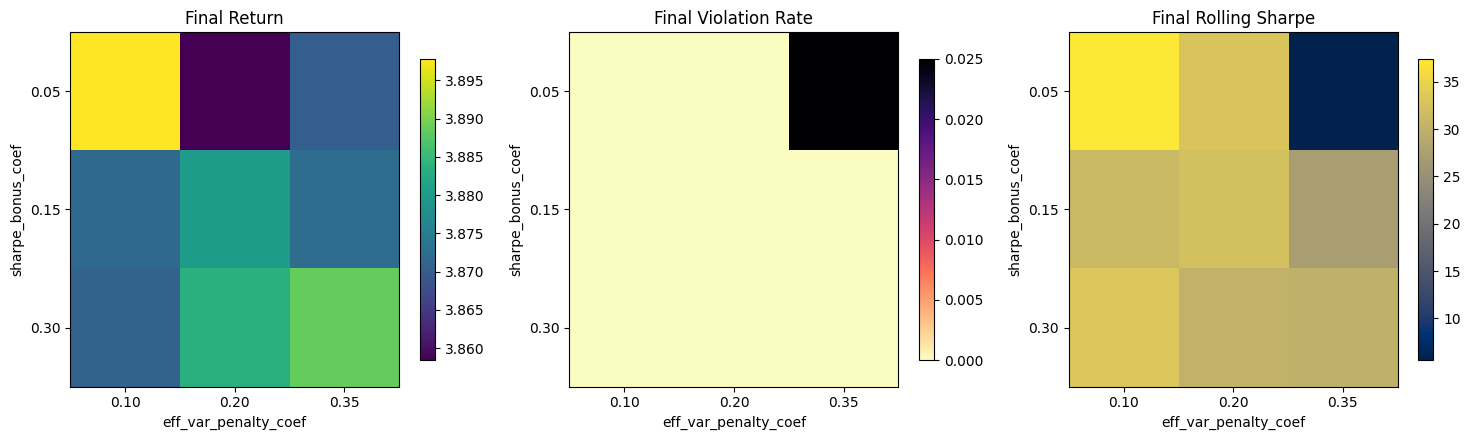

In [19]:
# Sensitivity sweep: GSPO/GRPO shaping coefficients
# Grid over (sharpe_bonus_coef, eff_var_penalty_coef), with compact training runs.

class ConstrainedMetaPathTrainerSweep(ConstrainedMetaPathTrainer):
    """Trainer variant exposing shaping coefficients for sensitivity analysis."""

    def __init__(
        self,
        episodes: int = 200,
        gamma: float = 0.97,
        seed: int = 1234,
        sharpe_bonus_coef: float = 0.15,
        eff_var_penalty_coef: float = 0.2,
    ) -> None:
        """Initialize sweep trainer with configurable shaping coefficients."""
        super().__init__(episodes=episodes, gamma=gamma, seed=seed)
        self.sharpe_bonus_coef = sharpe_bonus_coef
        self.eff_var_penalty_coef = eff_var_penalty_coef

    def train(self) -> dict:
        """Train while applying configurable Sharpe bonus and efficiency variance penalty."""
        recent_returns: List[float] = []
        recent_viols: List[float] = []
        recent_eff: List[float] = []

        for _ in range(1, self.episodes + 1):
            state = self.env.reset()
            done = False
            traj_sa: List[Tuple[State, Action]] = []
            rewards: List[float] = []
            violation = 0.0
            step_count = 0

            while not done:
                actions = self.env.available_actions(state)
                if not actions:
                    break
                risk_scores = {a: self.env.graph[state][a][2] * (1.0 + max(0.0, self.env.drift_level)) for a in actions}
                risk_limit = 0.05 / self.pid.goal_scale
                action = self.policy.sample_action(state, actions, risk_scores, risk_limit)
                sr = self.env.step(action, risk_limit)
                traj_sa.append((state, action))
                rewards.append(sr.reward)
                violation = max(violation, 1.0 if sr.compliance_violation else 0.0)
                state = sr.next_state
                done = sr.done
                step_count += 1

            returns = self._discounted_returns(rewards)
            ep_return = float(np.sum(rewards))
            efficiency = ep_return / max(step_count, 1)
            recent_eff.append(efficiency)
            eff_var = float(np.var(recent_eff[-30:])) if recent_eff else 0.0

            recent_returns.append(ep_return)
            sharpe = self._sharpe_like(np.array(recent_returns[-40:], dtype=np.float64))

            cost = 1.0 if violation > 0 else 0.0
            recent_viols.append(cost)
            viol_rate = float(np.mean(recent_viols[-40:]))

            drift_signal = max(0.0, self.env.drift_level)
            safety_weight, goal_scale = self.pid.update(viol_rate, drift_signal)

            shaped = returns.copy()
            shaped += self.sharpe_bonus_coef * sharpe
            shaped -= self.eff_var_penalty_coef * eff_var
            shaped -= (self.lambda_cost + safety_weight) * cost
            shaped *= goal_scale

            baseline = float(np.mean(shaped)) if shaped.size else 0.0
            adv = shaped - baseline
            grads: Dict[Tuple[State, Action], float] = {}
            for (s, a), a_t in zip(traj_sa, adv):
                grads[(s, a)] = grads.get((s, a), 0.0) + float(a_t)
            self.policy.update_logits(grads, lr=0.07)

            self.lambda_cost = max(0.0, self.lambda_cost + self.lambda_lr * viol_rate)

            self.history["return"].append(ep_return)
            self.history["rolling_sharpe"].append(sharpe)
            self.history["rolling_violation_rate"].append(viol_rate)
            self.history["safety_weight"].append(safety_weight)
            self.history["goal_scale"].append(goal_scale)
            self.history["lambda_cost"].append(self.lambda_cost)

        return self.history


# Small grid centered around the current defaults (0.15, 0.20)
sharpe_grid = [0.05, 0.15, 0.30]
eff_var_grid = [0.10, 0.20, 0.35]

sweep_rows = []
for i, sharpe_coef in enumerate(sharpe_grid):
    for j, eff_var_coef in enumerate(eff_var_grid):
        run_seed = 100 + i * 10 + j
        sweep_trainer = ConstrainedMetaPathTrainerSweep(
            episodes=200,
            gamma=0.97,
            seed=run_seed,
            sharpe_bonus_coef=sharpe_coef,
            eff_var_penalty_coef=eff_var_coef,
        )
        h = sweep_trainer.train()
        sweep_rows.append(
            {
                "sharpe_coef": sharpe_coef,
                "eff_var_coef": eff_var_coef,
                "final_return": float(np.mean(h["return"][-20:])),
                "final_violation": float(np.mean(h["rolling_violation_rate"][-20:])),
                "final_sharpe": float(np.mean(h["rolling_sharpe"][-20:])),
            }
        )

# Sort by safer + higher return preference
sweep_rows = sorted(sweep_rows, key=lambda x: (x["final_violation"], -x["final_return"], -x["final_sharpe"]))

print("Top coefficient settings (lower violation first):")
for row in sweep_rows:
    print(
        f"sharpe_coef={row['sharpe_coef']:.2f}, eff_var_coef={row['eff_var_coef']:.2f} | "
        f"return={row['final_return']:+.3f}, violation={row['final_violation']:.3f}, sharpe={row['final_sharpe']:+.3f}"
    )

# Plot sensitivity surfaces as heatmaps
ret_mat = np.zeros((len(sharpe_grid), len(eff_var_grid)))
viol_mat = np.zeros((len(sharpe_grid), len(eff_var_grid)))
sharpe_mat = np.zeros((len(sharpe_grid), len(eff_var_grid)))

for row in sweep_rows:
    i = sharpe_grid.index(row["sharpe_coef"])
    j = eff_var_grid.index(row["eff_var_coef"])
    ret_mat[i, j] = row["final_return"]
    viol_mat[i, j] = row["final_violation"]
    sharpe_mat[i, j] = row["final_sharpe"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

im0 = axes[0].imshow(ret_mat, cmap="viridis", aspect="auto")
axes[0].set_title("Final Return")
axes[0].set_xlabel("eff_var_penalty_coef")
axes[0].set_ylabel("sharpe_bonus_coef")
axes[0].set_xticks(range(len(eff_var_grid)), [f"{x:.2f}" for x in eff_var_grid])
axes[0].set_yticks(range(len(sharpe_grid)), [f"{x:.2f}" for x in sharpe_grid])
fig.colorbar(im0, ax=axes[0], shrink=0.85)

im1 = axes[1].imshow(viol_mat, cmap="magma_r", aspect="auto")
axes[1].set_title("Final Violation Rate")
axes[1].set_xlabel("eff_var_penalty_coef")
axes[1].set_ylabel("sharpe_bonus_coef")
axes[1].set_xticks(range(len(eff_var_grid)), [f"{x:.2f}" for x in eff_var_grid])
axes[1].set_yticks(range(len(sharpe_grid)), [f"{x:.2f}" for x in sharpe_grid])
fig.colorbar(im1, ax=axes[1], shrink=0.85)

im2 = axes[2].imshow(sharpe_mat, cmap="cividis", aspect="auto")
axes[2].set_title("Final Rolling Sharpe")
axes[2].set_xlabel("eff_var_penalty_coef")
axes[2].set_ylabel("sharpe_bonus_coef")
axes[2].set_xticks(range(len(eff_var_grid)), [f"{x:.2f}" for x in eff_var_grid])
axes[2].set_yticks(range(len(sharpe_grid)), [f"{x:.2f}" for x in sharpe_grid])
fig.colorbar(im2, ax=axes[2], shrink=0.85)

plt.tight_layout()
plt.show()

In [20]:
# Apply saved policy to new cases (unseen drifts)
new_case_drifts = [-0.20, 0.00, 0.12, 0.25, 0.40]
case_results = apply_policy_on_new_cases(str(policy_path), new_case_drifts, seed=1234)

print("\nPolicy decisions on new cases:")
for row in case_results:
    print(
        f"case={row['case_id']} drift={row['drift']:+.2f} "
        f"reward={row['total_reward']:+.3f} violation={row['violation']} "
        f"path={row['path']}"
    )


Policy decisions on new cases:
case=1 drift=-0.20 reward=+4.000 violation=False path=verify_eligibility -> collect_history -> evidence_based_plan -> monitor_outcome
case=2 drift=+0.00 reward=+4.000 violation=False path=verify_eligibility -> collect_history -> evidence_based_plan -> monitor_outcome
case=3 drift=+0.12 reward=+3.904 violation=False path=verify_eligibility -> collect_history -> evidence_based_plan -> monitor_outcome
case=4 drift=+0.25 reward=+3.800 violation=False path=verify_eligibility -> collect_history -> evidence_based_plan -> monitor_outcome
case=5 drift=+0.40 reward=+3.680 violation=False path=verify_eligibility -> collect_history -> evidence_based_plan -> monitor_outcome


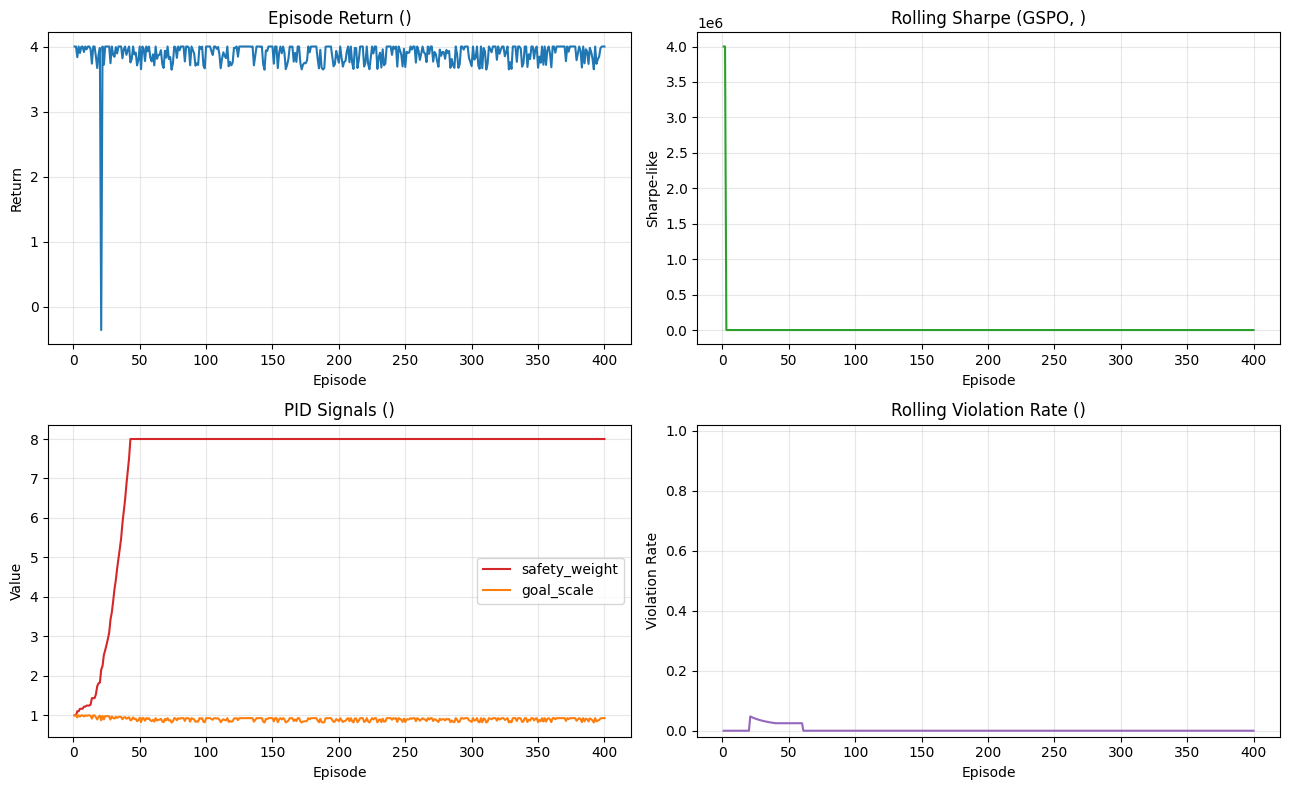

In [21]:
# Optional: plot  training metrics (same four requested views)
episodes_ = np.arange(1, len(history_['return']) + 1)

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

axes[0, 0].plot(episodes_, history_['return'], color='tab:blue', linewidth=1.5)
axes[0, 0].set_title('Episode Return ()')
axes[0, 0].set_xlabel('Episode')
axes[0, 0].set_ylabel('Return')
axes[0, 0].grid(alpha=0.3)

axes[0, 1].plot(episodes_, history_['rolling_sharpe'], color='tab:green', linewidth=1.5)
axes[0, 1].set_title('Rolling Sharpe (GSPO, )')
axes[0, 1].set_xlabel('Episode')
axes[0, 1].set_ylabel('Sharpe-like')
axes[0, 1].grid(alpha=0.3)

axes[1, 0].plot(episodes_, history_['safety_weight'], label='safety_weight', color='tab:red', linewidth=1.5)
axes[1, 0].plot(episodes_, history_['goal_scale'], label='goal_scale', color='tab:orange', linewidth=1.5)
axes[1, 0].set_title('PID Signals ()')
axes[1, 0].set_xlabel('Episode')
axes[1, 0].set_ylabel('Value')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

axes[1, 1].plot(episodes_, history_['rolling_violation_rate'], color='tab:purple', linewidth=1.5)
axes[1, 1].set_title('Rolling Violation Rate ()')
axes[1, 1].set_xlabel('Episode')
axes[1, 1].set_ylabel('Violation Rate')
axes[1, 1].set_ylim(-0.02, 1.02)
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()